# TELCO CUSTOMER CHURN PREDICTION

A telecom company is facing a significant **customer churn problem**, where customers are leaving the company and switching to competitors. Each customer who leaves results in **lost revenue** and increases the company's **customer acquisition costs**.

The company currently needs a way to identify customers who are **likely to churn before they actually leave**. By predicting customer churn in advance, the company can take proactive actions such as providing personalized offers, discounts, better support, or loyalty benefits.

The objective of this project is to develop a **Machine Learning-based Customer Churn Prediction System** that analyzes customer demographic, service, tenure, contract, and billing information to:

- Identify customers who are likely to **churn**.
- Identify customers who are likely to **stay**.
- Predict the **probability of churn** for each customer.
- Evaluate the prediction performance using suitable classification metrics.
- Identify incorrect predictions using a **confusion matrix**.
- Provide **business insights** that can support customer retention strategies.

The ultimate goal is to help the telecom company **reduce customer churn, improve customer retention, and minimize revenue loss** through data-driven decision-making.

 1. Import required libraries

In [39]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



# 2. Load Dataset

In [40]:
df = pd.read_csv(r"C:\Ai_assistant\python practice\ML\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

First 5 records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

# 3. Understand the Dataset

In [41]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# 4. Data Cleaning

In [42]:
# TotalCharges contains some blank values
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
df = df.dropna()

# Remove customerID because it is only an identifier
df = df.drop("customerID", axis=1)

# Convert Yes/No columns and target
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# 5. Convert Categorical Variables

In [43]:
# Convert categorical variables into numerical dummy variables
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print("\nProcessed Dataset:")
print(df.head())

print("\nProcessed Shape:")
print(df.shape)




Processed Dataset:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                               0  ...          

# 6. Separate Input Features and Target

In [44]:

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nNumber of Features:", X.shape[1])


Number of Features: 30


# 7. Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])




Training Records: 5625
Testing Records: 1407


# 8. Feature Scaling

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Build Logistic Regression Model

In [47]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\nModel Training Completed!")




Model Training Completed!


# 10. Predict Churn

In [48]:

y_pred = model.predict(X_test_scaled)

# Probability of Churn
y_probability = model.predict_proba(X_test_scaled)[:, 1]



# 11. Display Predictions

In [49]:

results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Churn_Probability": y_probability,
    "Predicted_Churn": y_pred
})

results["Prediction"] = results["Predicted_Churn"].map({
    1: "Likely to Churn",
    0: "Likely to Stay"
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual_Churn  Churn_Probability  Predicted_Churn       Prediction
0             0           0.017115                0   Likely to Stay
1             0           0.596132                1  Likely to Churn
2             0           0.004764                0   Likely to Stay
3             1           0.200044                0   Likely to Stay
4             0           0.100222                0   Likely to Stay
5             1           0.470029                0   Likely to Stay
6             0           0.026611                0   Likely to Stay
7             0           0.164149                0   Likely to Stay
8             1           0.686141                1  Likely to Churn
9             0           0.015180                0   Likely to Stay


# 12. Evaluation Metrics

In [50]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probability)

print("\n========== MODEL PERFORMANCE ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")




========== MODEL PERFORMANCE ==========
Accuracy  : 0.8038
Precision : 0.6476
Recall    : 0.5749
F1 Score  : 0.6091
ROC-AUC   : 0.8357


# 13. Classification Report

In [51]:

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Churn", "Churn"]
))




Classification Report:


              precision    recall  f1-score   support

   Non-Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# 14. Confusion Matrix

In [52]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)




Confusion Matrix:
[[916 117]
 [159 215]]

True Negatives : 916
False Positives: 117
False Negatives: 159
True Positives : 215


# 15. Business Interpretation

In [53]:
print("\n========== BUSINESS INTERPRETATION ==========")

print(f"Customers correctly identified as churn: {TP}")
print(f"Non-churn customers wrongly flagged: {FP}")
print(f"Churn customers missed by the model: {FN}")
print(f"Non-churn customers correctly identified: {TN}")




========== BUSINESS INTERPRETATION ==========
Customers correctly identified as churn: 215
Non-churn customers wrongly flagged: 117
Churn customers missed by the model: 159
Non-churn customers correctly identified: 916


# 16. ROC Curve

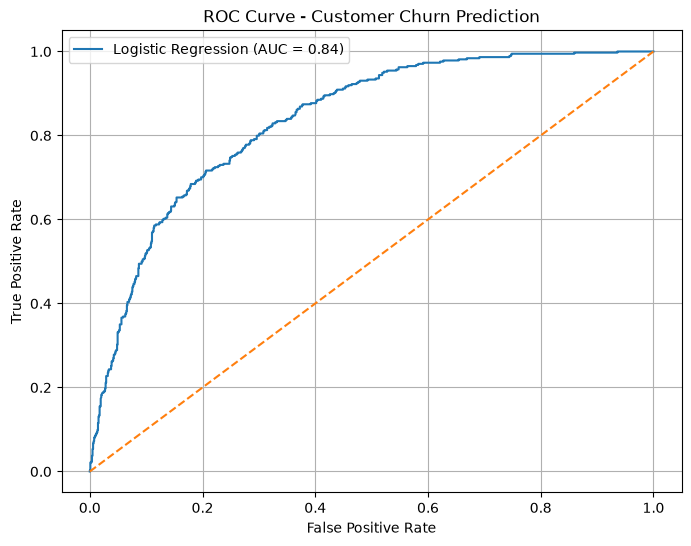

In [54]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid()

plt.show()

In [55]:
new_customer = pd.DataFrame({
    "tenure": [5],
    "MonthlyCharges": [95],
    "TotalCharges": [475]
})

In [56]:
new_customer = X.iloc[[0]].copy()

# Example: modify some values
new_customer["tenure"] = 5
new_customer["MonthlyCharges"] = 95
new_customer["TotalCharges"] = 475

new_customer_scaled = scaler.transform(new_customer)

probability = model.predict_proba(new_customer_scaled)[0][1]

prediction = model.predict(new_customer_scaled)[0]

print("Churn Probability:", probability)

if prediction == 1:
    print("Prediction: Likely to Churn")
else:
    print("Prediction: Likely to Stay")

Churn Probability: 0.1913900173347263
Prediction: Likely to Stay


In [57]:
threshold = 0.40

y_pred_custom = (y_probability >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_custom,
    target_names=["Non-Churn", "Churn"]
))

              precision    recall  f1-score   support

   Non-Churn       0.88      0.82      0.85      1033
       Churn       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



## Conclusion

A **Logistic Regression** model was developed to predict customer churn using demographic, service, tenure, contract, and billing-related attributes.

The model generates a **probability of churn** and classifies customers as either:

- **Likely to Churn**
- **Likely to Stay**

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

For this business problem, **recall for the churn class** is particularly important because failing to identify a customer who is likely to leave can result in significant revenue loss.

A useful improvement would be to **optimize the classification threshold** based on the business cost of false positives and false negatives.

This model can therefore support **targeted retention campaigns** by allowing the company to focus offers and interventions on customers with a high probability of churn.